# Stock Price Prediction Using RNNs

## Objective
The objective of this assignment is to try and predict the stock prices using historical data from four companies IBM (IBM), Google (GOOGL), Amazon (AMZN), and Microsoft (MSFT).

We use four different companies because they belong to the same sector: Technology. Using data from all four companies may improve the performance of the model. This way, we can capture the broader market sentiment.

The problem statement for this assignment can be summarised as follows:

> Given the stock prices of Amazon, Google, IBM, and Microsoft for a set number of days, predict the stock price of these companies after that window.

## Business Value

Data related to stock markets lends itself well to modeling using RNNs due to its sequential nature. We can keep track of opening prices, closing prices, highest prices, and so on for a long period of time as these values are generated every working day. The patterns observed in this data can then be used to predict the future direction in which stock prices are expected to move. Analyzing this data can be interesting in itself, but it also has a financial incentive as accurate predictions can lead to massive profits.

### **Data Description**

You have been provided with four CSV files corresponding to four stocks: AMZN, GOOGL, IBM, and MSFT. The files contain historical data that were gathered from the websites of the stock markets where these companies are listed: NYSE and NASDAQ. The columns in all four files are identical. Let's take a look at them:

- `Date`: The values in this column specify the date on which the values were recorded. In all four files, the dates range from Jaunary 1, 2006 to January 1, 2018.

- `Open`: The values in this column specify the stock price on a given date when the stock market opens.

- `High`: The values in this column specify the highest stock price achieved by a stock on a given date.

- `Low`: The values in this column specify the lowest stock price achieved by a stock on a given date.

- `Close`: The values in this column specify the stock price on a given date when the stock market closes.

- `Volume`: The values in this column specify the total number of shares traded on a given date.

- `Name`: This column gives the official name of the stock as used in the stock market.

There are 3019 records in each data set. The file names are of the format `\<company_name>_stock_data.csv`.

## **1 Data Loading and Preparation** <font color =red> [25 marks] </font>

#### **Import Necessary Libraries**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, InputLayer
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, InputLayer

import warnings
warnings.filterwarnings("ignore")

### **1.1 Data Aggregation** <font color =red> [7 marks] </font>

As we are using the stock data for four different companies, we need to create a new DataFrame that contains the combined data from all four data frames. We will create a function that takes in a list of the file names for the four CSV files, and returns a single data frame. This function performs the following tasks:
- Extract stock names from file names
- Read the CSV files as data frames
- Append the stock names into the columns of their respective data frames
- Drop unnecessary columns
- Join the data frames into one.

#### **1.1.1** <font color =red> [5 marks] </font>
Create the function to join DataFrames and use it to combine the four datasets.

In [2]:
def combine_stock_data_append_all_columns(file_list):
    combined_list = []
    for file in file_list:
        df = pd.read_csv(file)
        df.columns = [col.strip() for col in df.columns]
        combined_list.append(df)
    combined_df = pd.concat(combined_list, ignore_index=True)
    combined_df['Date'] = pd.to_datetime(combined_df['Date'])
    combined_df.sort_values(['Name', 'Date'], inplace=True)
    combined_df.reset_index(drop=True, inplace=True)
    return combined_df

In [3]:
file_list = [
    r'C:\Users\4270\Documents\Upgrad\RNN\RNN_Stock_Starter_Dataset\RNN_Stock_Starter_Dataset\RNN_Stocks_Data\AMZN_stocks_data.csv',
    r'C:\Users\4270\Documents\Upgrad\RNN\RNN_Stock_Starter_Dataset\RNN_Stock_Starter_Dataset\RNN_Stocks_Data\GOOGL_stocks_data.csv',
    r'C:\Users\4270\Documents\Upgrad\RNN\RNN_Stock_Starter_Dataset\RNN_Stock_Starter_Dataset\RNN_Stocks_Data\IBM_stocks_data.csv',
    r'C:\Users\4270\Documents\Upgrad\RNN\RNN_Stock_Starter_Dataset\RNN_Stock_Starter_Dataset\RNN_Stocks_Data\MSFT_stocks_data.csv'
]

combined_df = combine_stock_data_append_all_columns(file_list)
print(combined_df.head())


        Date   Open   High    Low  Close   Volume  Name
0 2006-01-03  47.47  47.85  46.25  47.58  7582127  AMZN
1 2006-01-04  47.48  47.73  46.69  47.25  7440914  AMZN
2 2006-01-05  47.16  48.20  47.11  47.65  5417258  AMZN
3 2006-01-06  47.97  48.58  47.32  47.87  6154285  AMZN
4 2006-01-09  46.55  47.10  46.40  47.08  8945056  AMZN


In [4]:
# View specifics of the data

print(combined_df.head())
print(combined_df.info())
print(combined_df.describe())
print(combined_df.isnull().sum())
print(combined_df.shape)

        Date   Open   High    Low  Close   Volume  Name
0 2006-01-03  47.47  47.85  46.25  47.58  7582127  AMZN
1 2006-01-04  47.48  47.73  46.69  47.25  7440914  AMZN
2 2006-01-05  47.16  48.20  47.11  47.65  5417258  AMZN
3 2006-01-06  47.97  48.58  47.32  47.87  6154285  AMZN
4 2006-01-09  46.55  47.10  46.40  47.08  8945056  AMZN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12077 entries, 0 to 12076
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    12077 non-null  datetime64[ns]
 1   Open    12076 non-null  float64       
 2   High    12077 non-null  float64       
 3   Low     12076 non-null  float64       
 4   Close   12077 non-null  float64       
 5   Volume  12077 non-null  int64         
 6   Name    12077 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 660.6+ KB
None
                                Date          Open          High  \
coun

#### **1.1.2** <font color =red> [2 marks] </font>
Identify and handle any missing values.

In [5]:
# Handle Missing Values

print(combined_df.isnull().sum())
df = combined_df.fillna(method='ffill')
df = combined_df.dropna()
df.dropna(inplace=True)

Date      0
Open      1
High      0
Low       1
Close     0
Volume    0
Name      0
dtype: int64


### **1.2 Analysis and Visualisation** <font color =red> [5 marks] </font>

#### **1.2.1** <font color =red> [2 marks] </font>
Analyse the frequency distribution of stock volumes of the companies and also see how the volumes vary over time.

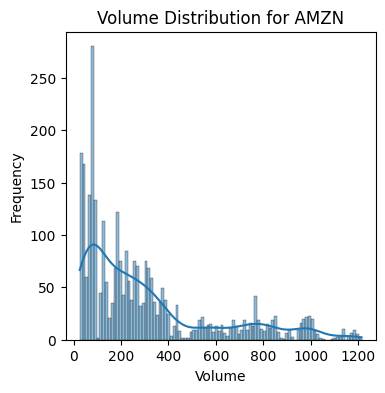

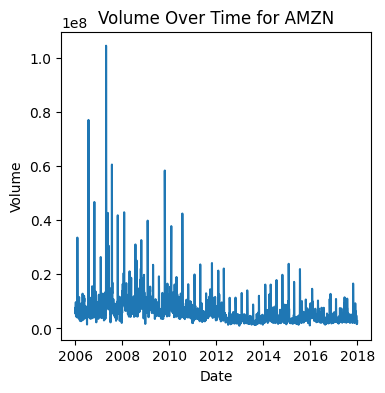

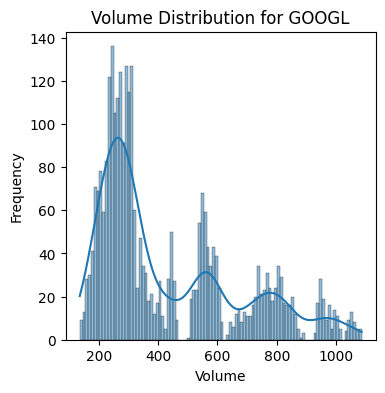

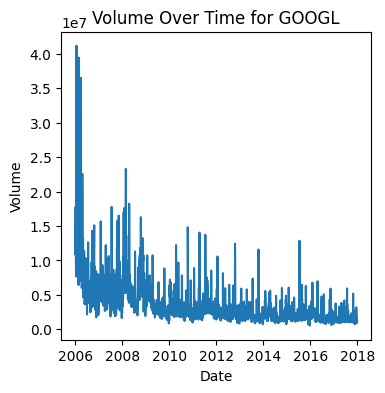

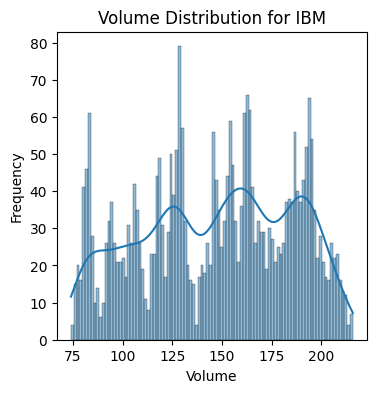

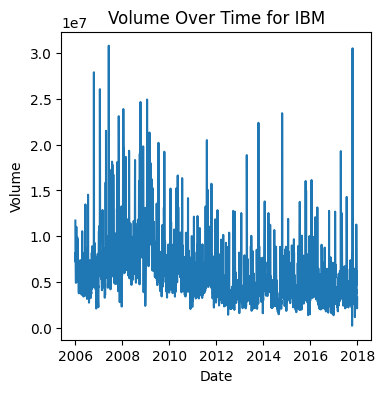

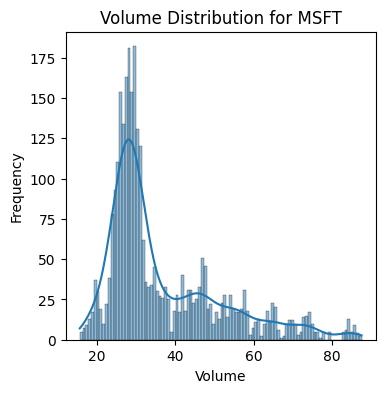

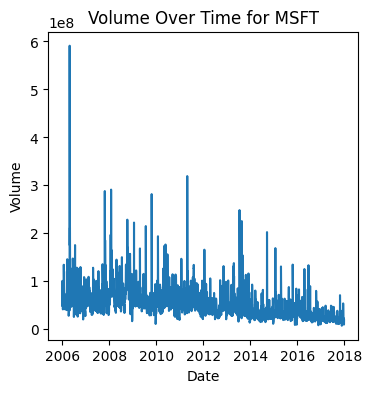

In [6]:
# Frequency distribution of volumes
def analyze_volume_distribution(df):
    stocks = df['Name'].unique()
    for stock in stocks:
        stock_data = df[df['Name'] == stock]
        plt.figure(figsize=(4, 4))
        sns.histplot(stock_data['High'], bins=100, kde=True)
        plt.title(f'Volume Distribution for {stock}')
        plt.xlabel('Volume')
        plt.ylabel('Frequency')
        plt.show()
        
        plt.figure(figsize=(4, 4))
        plt.plot(stock_data['Date'], stock_data['Volume'])
        plt.title(f'Volume Over Time for {stock}')
        plt.xlabel('Date')
        plt.ylabel('Volume')
        plt.show()
analyze_volume_distribution(df)

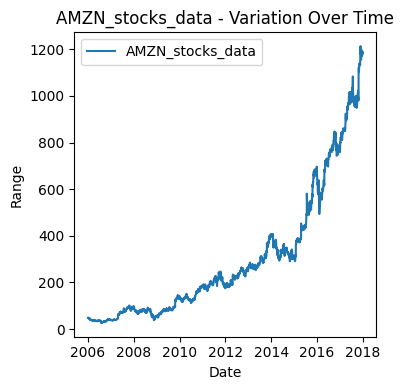

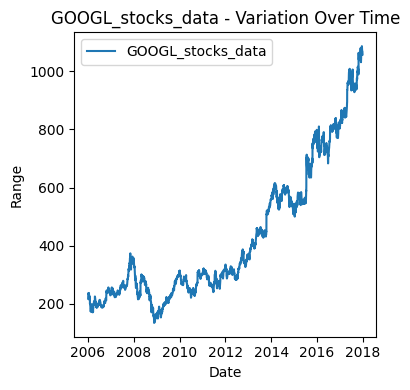

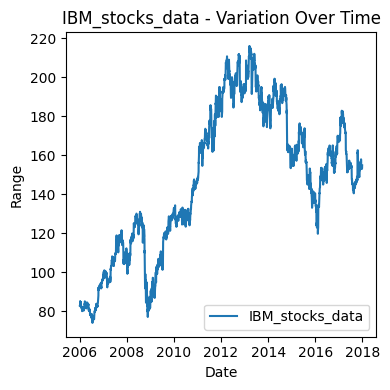

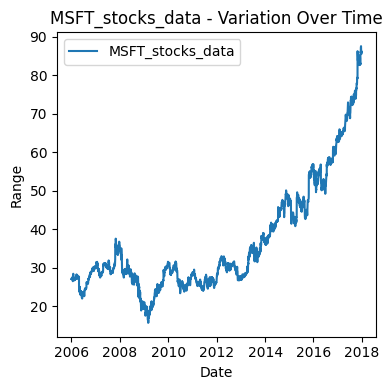

In [7]:
# Stock volume variation over time
def plot_volume_over_time(file_list):
    for file in file_list:
        stock_name = os.path.splitext(os.path.basename(file))[0]
        df = pd.read_csv(file)
        df.columns = [col.strip() for col in df.columns]
        if 'Volume' not in df.columns:
            continue
        df['Date'] = pd.to_datetime(df['Date'])
        plt.figure(figsize=(4, 4))
        plt.plot(df['Date'], df['High'], label=stock_name)
        plt.title(f'{stock_name} - Variation Over Time')
        plt.xlabel('Date')
        plt.ylabel('Range')
        plt.legend()
        plt.tight_layout()
        plt.show()
plot_volume_over_time(file_list)

#### **1.2.2** <font color =red> [3 marks] </font>
Analyse correlations between features.

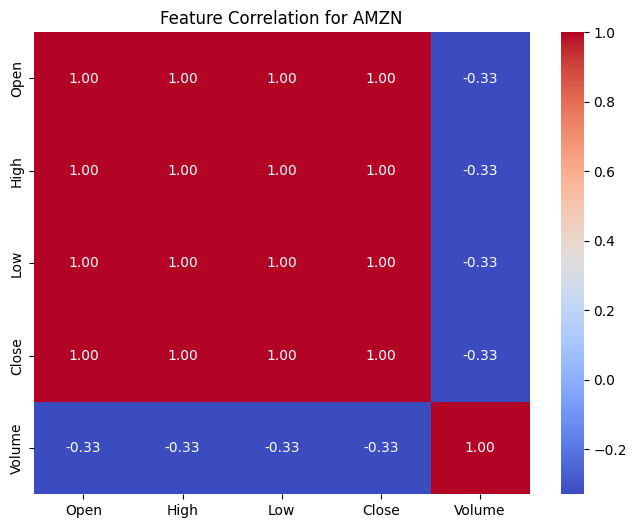

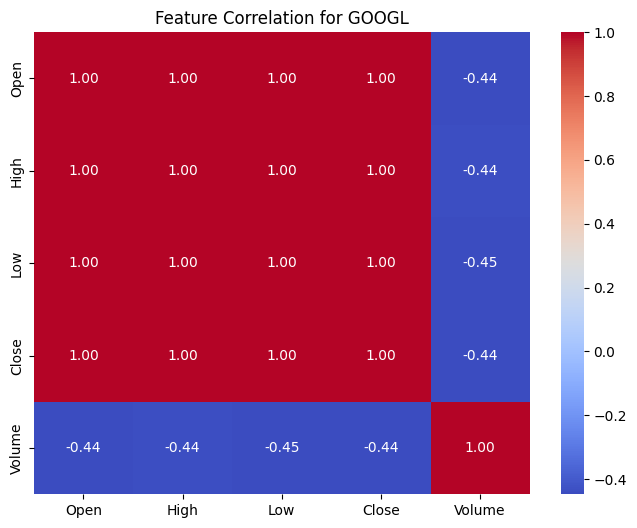

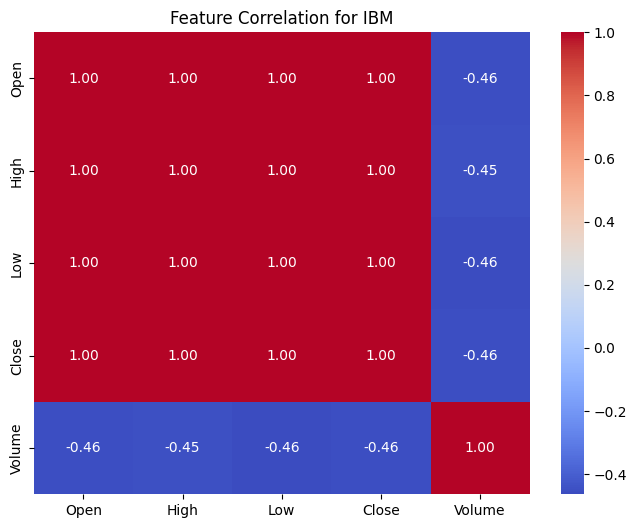

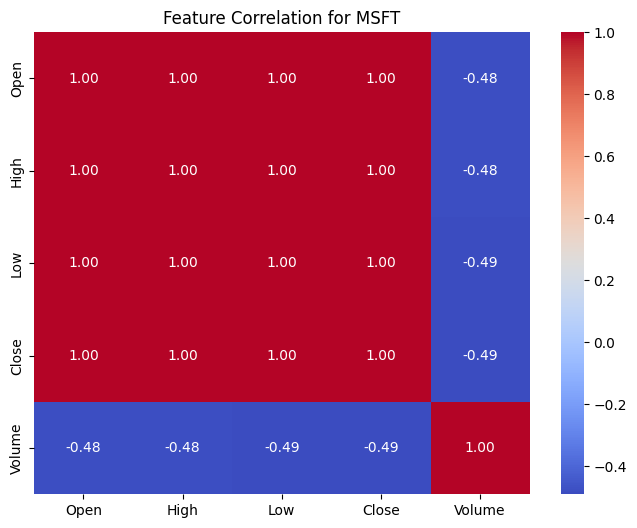

In [8]:
# Analyse correlations
def analyze_feature_correlations(df):
    stocks = df['Name'].unique()
    for stock in stocks:
        stock_data = df[df['Name'] == stock]
        corr = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title(f'Feature Correlation for {stock}')
        plt.show()

analyze_feature_correlations(combined_df)

### **1.3 Data Processing** <font color =red> [13 marks] </font>

Next, we need to process the data so that it is ready to be used in recurrent neural networks. You know RNNs are suitable to work with sequential data where patterns repeat at regular intervals.

For this, we need to execute the following steps:
1. Create windows from the master data frame and obtain windowed `X` and corresponding windowed `y` values
2. Perform train-test split on the windowed data
3. Scale the data sets in an appropriate manner

We will define functions for the above steps that finally return training and testing data sets that are ready to be used in recurrent neural networks.

**Hint:** If we use a window of size 3, in the first window, the rows `[0, 1, 2]` will be present and will be used to predict the value of `CloseAMZN` in row `3`. In the second window, rows `[1, 2, 3]` will be used to predict `CloseAMZN` in row `4`.

#### **1.3.1** <font color =red> [3 marks] </font>
Create a function that returns the windowed `X` and `y` data.

From the main DataFrame, this function will create windowed DataFrames, and store those as a list of DataFrames.

Controllable parameters will be window size, step size (window stride length) and target names as a list of the names of stocks whose closing values we wish to predict.

In [9]:
def create_windowed_data(df, window_size, step_size, target_names):
    X_data = {}
    y_data = {}
    for target in target_names:
        stock_df = df[df['Name'] == target].sort_values('Date')
        stock_values = stock_df[['Open', 'High', 'Low', 'Close', 'Volume']].values
        X_list = []
        y_list = []
        for i in range(0, len(stock_values) - window_size, step_size):
            X_list.append(stock_values[i:i+window_size])
            y_list.append(stock_values[i+window_size][3])
        X_data[target] = np.array(X_list)
        y_data[target] = np.array(y_list)
    return X_data, y_data

In [10]:
target_names = df['Name'].unique()
X_data, y_data = create_windowed_data(df, window_size=3, step_size=3, target_names=target_names)


for stock in X_data:
    print(stock, X_data[stock].shape, y_data[stock].shape)
    break

AMZN (1006, 3, 5) (1006,)


#### **1.3.2** <font color =red> [3 marks] </font>
Create a function to scale the data.

Define a function that will scale the data.

For scaling, we have to look at the whole length of data to find max/min values or standard deviations and means. If we scale the whole data at once, this will lead to data leakage in the windows. This is not necessarily a problem if the model is trained on the complete data with cross-validation.

One way to scale when dealing with windowed data is to use the `partial_fit()` method.
```
scaler.partial_fit(window)
scaler.transform(window)
```
You may use any other suitable way to scale the data properly. Arrive at a reasonable way to scale your data.

In [11]:
# Define a function that scales the windowed data
# Define a function that scales the windowed data

def scale_windowed_data(X_data, y_data):
    X_scaled = {}
    y_scaled = {}
    for stock in X_data.keys():
        X_stock = X_data[stock]
        y_stock = y_data[stock].reshape(-1, 1)
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        for window in X_stock:
            scaler_X.partial_fit(window)
        scaler_y.partial_fit(y_stock)
        X_stock_scaled = np.array([scaler_X.transform(window) for window in X_stock])
        y_stock_scaled = scaler_y.transform(y_stock)
        X_scaled[stock] = X_stock_scaled
        y_scaled[stock] = y_stock_scaled.flatten()
    return X_scaled, y_scaled

X_scaled, y_scaled = scale_windowed_data(X_data, y_data)

for stock in X_scaled:
    print(stock, X_scaled[stock].shape, y_scaled[stock].shape)
    break

AMZN (1006, 3, 5) (1006,)


Next, define the main function that will call the windowing and scaling helper functions.

The input parameters for this function are:
- The joined master data set
- The names of the stocks that we wish to predict the *Close* prices for
- The window size
- The window stride
- The train-test split ratio

The outputs from this function are the scaled dataframes:
- *X_train*
- *y_train*
- *X_test*
- *y_test*

In [13]:
def prepare_rnn_data(df, target_names, window_size, step_size, split_ratio):
    X_data, y_data = create_windowed_data(df, window_size, step_size, target_names)
    X_scaled, y_scaled = scale_windowed_data(X_data, y_data)
    X_train_list, y_train_list = [], []
    X_test_list, y_test_list = [], []
    for stock in target_names:
        split_index = int(len(X_scaled[stock]) * split_ratio)
        X_train_list.append(X_scaled[stock][:split_index])
        y_train_list.append(y_scaled[stock][:split_index])
        X_test_list.append(X_scaled[stock][split_index:])
        y_test_list.append(y_scaled[stock][split_index:])
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)
    return X_train, y_train, X_test, y_test

#### **1.3.3** <font color =red> [3 marks] </font>
Define a function to create windows of `window_size` and split the windowed data in to training and validation sets.

The function can take arguments such as list of target names, window size, window stride and split ratio. Use the windowing function here to make windows in the data and then perform scaling and train-test split.

In [14]:
# Define a function to create input and output data points from the master DataFrame

X_train, y_train, X_test, y_test = prepare_rnn_data(
    df,
    target_names=combined_df['Name'].unique(),
    window_size=3,
    step_size=1,
    split_ratio=0.8
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(np.isnan(X_train).sum(), np.isnan(y_train).sum())
print(np.isnan(X_test).sum(), np.isnan(y_test).sum())

(9648, 3, 5) (9648,)
(2416, 3, 5) (2416,)
0 0
0 0


We can now use these helper functions to create our training and testing data sets. But first we need to decide on a length of windows. As we are doing time series prediction, we want to pick a sequence that shows some repetition of patterns.

For selecting a good sequence length, some business understanding will help us. In financial scenarios, we can either work with business days, weeks (which comprise of 5 working days), months, or quarters (comprising of 13 business weeks). Try looking for some patterns for these periods.

#### **1.3.4** <font color =red> [2 marks] </font>
Identify an appropriate window size.

For this, you can use plots to see how target variable is varying with time. Try dividing it into parts by weeks/months/quarters.

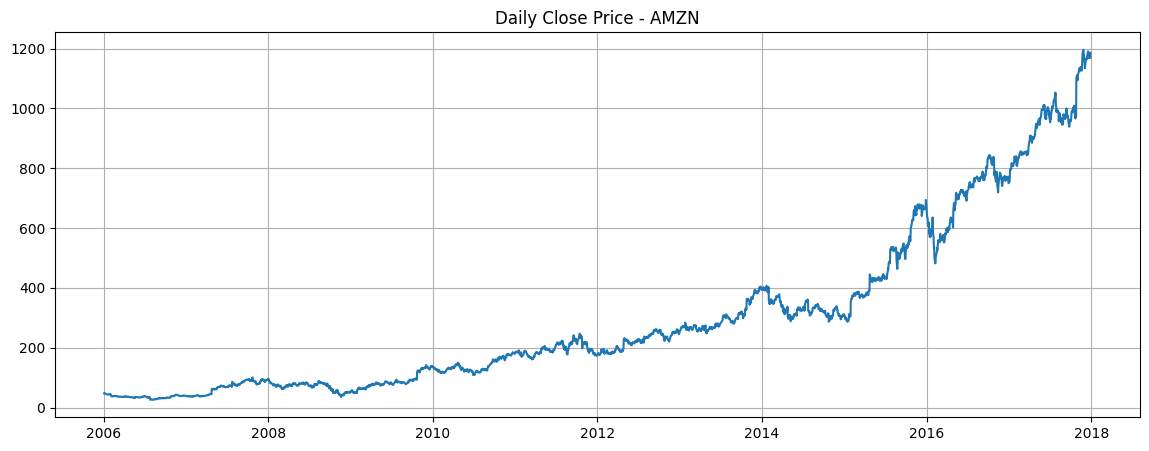

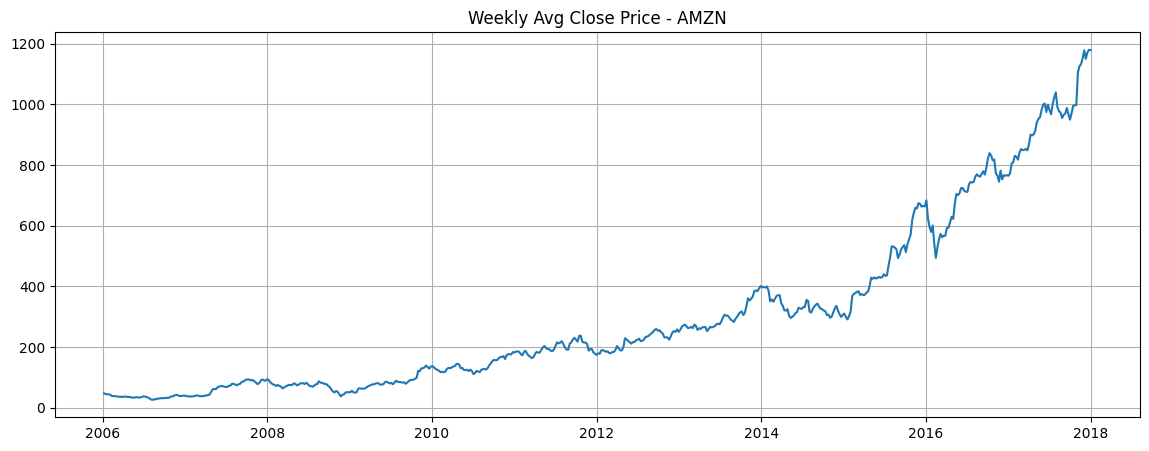

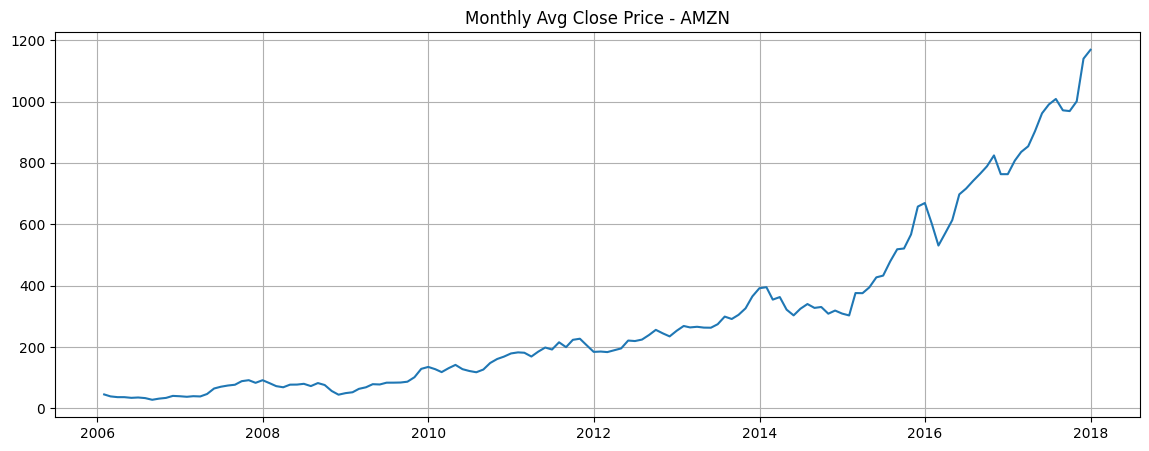

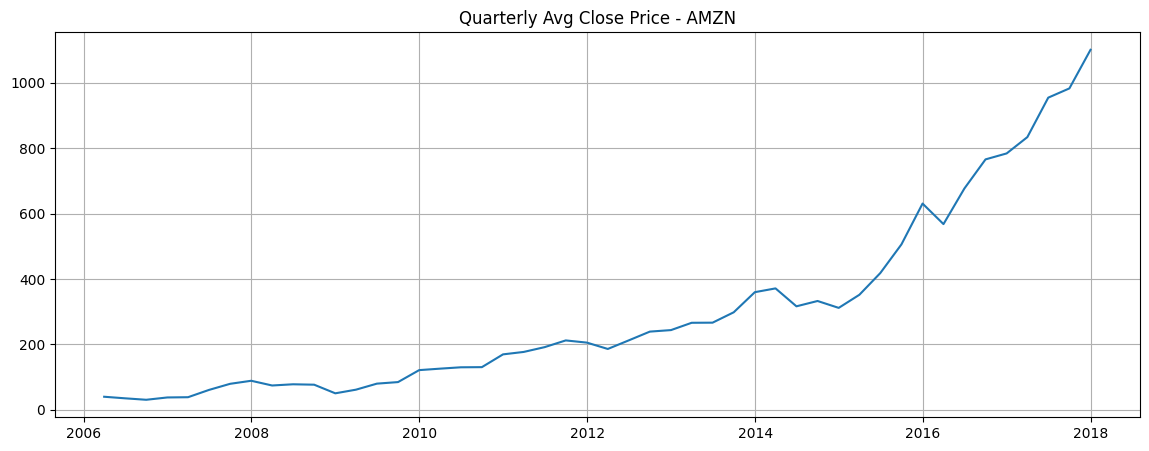

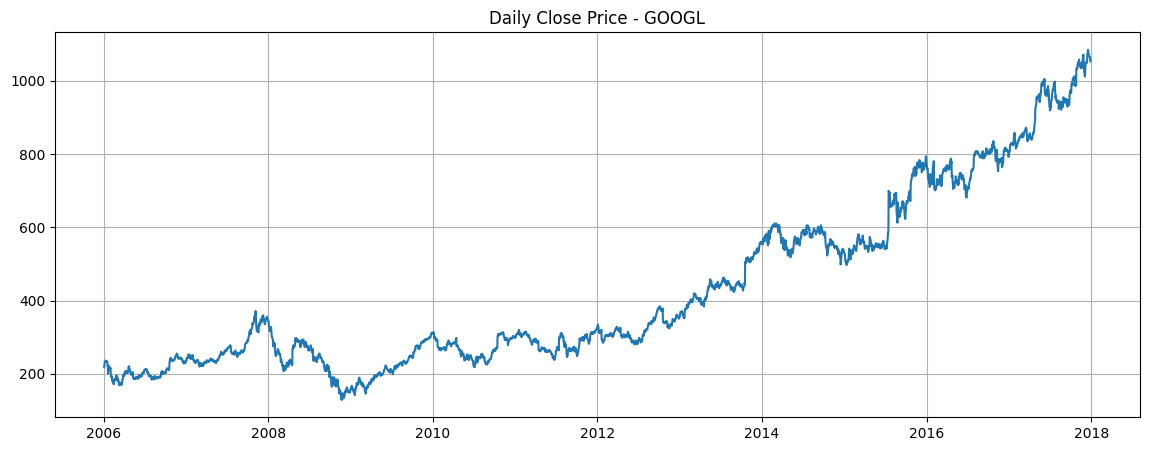

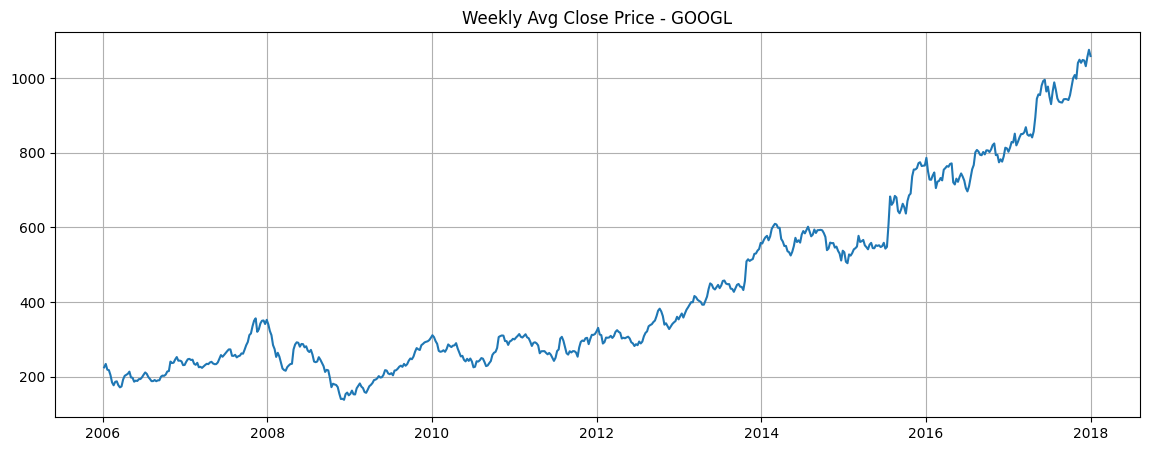

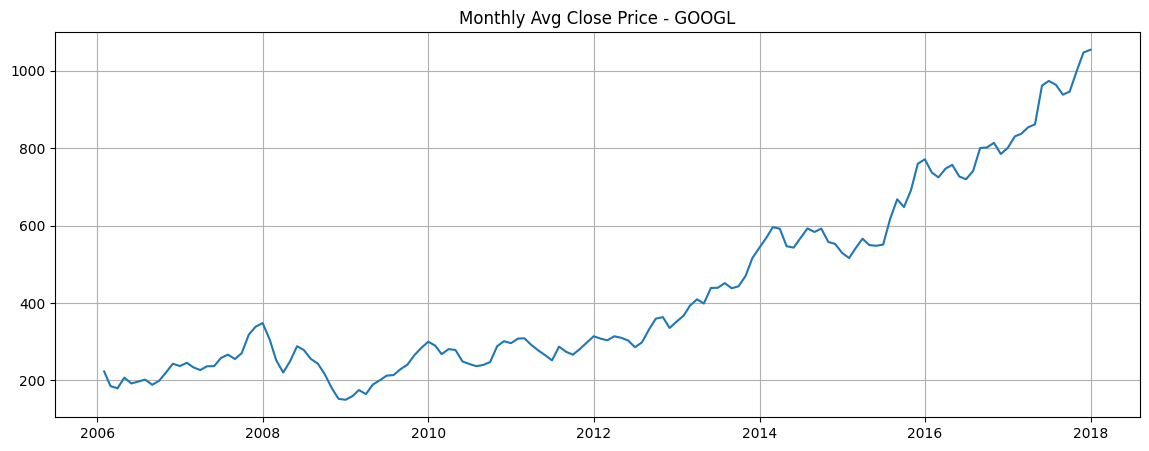

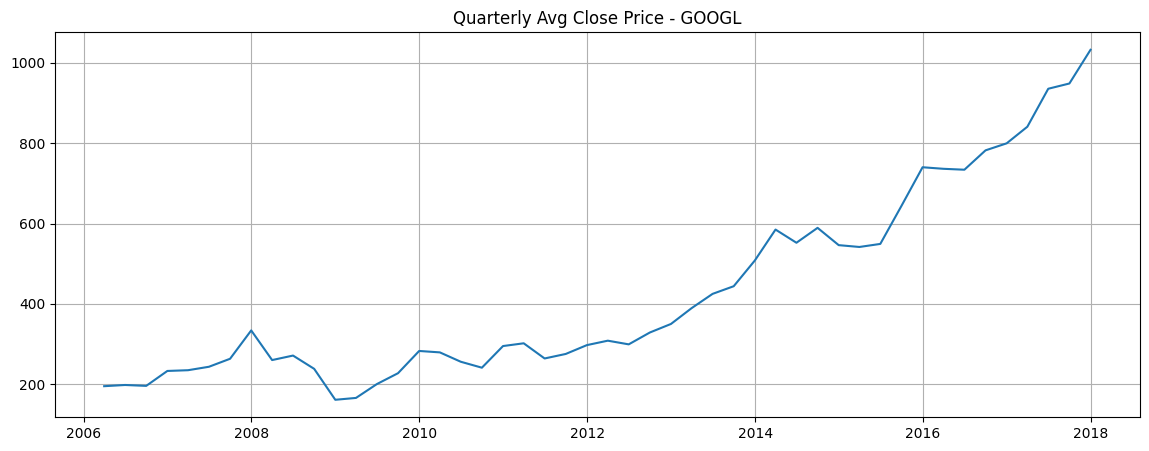

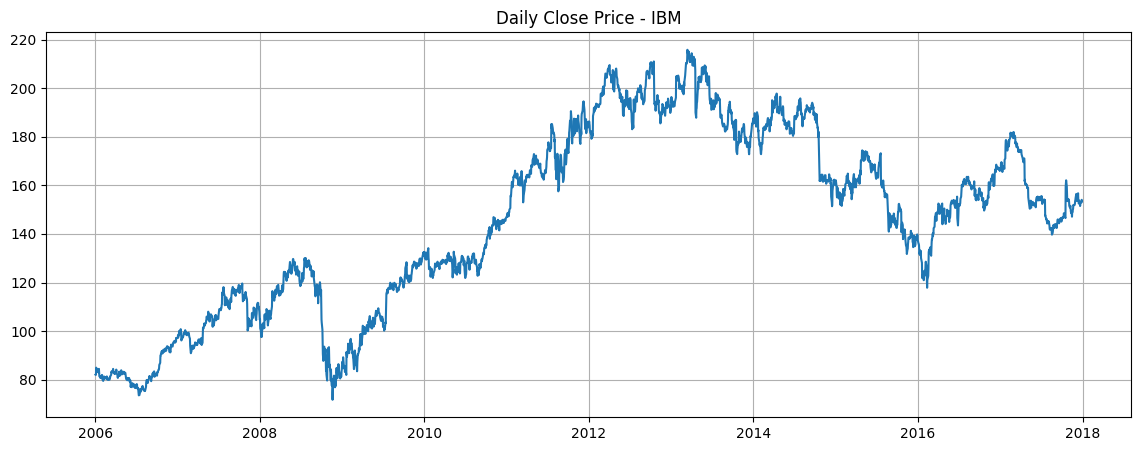

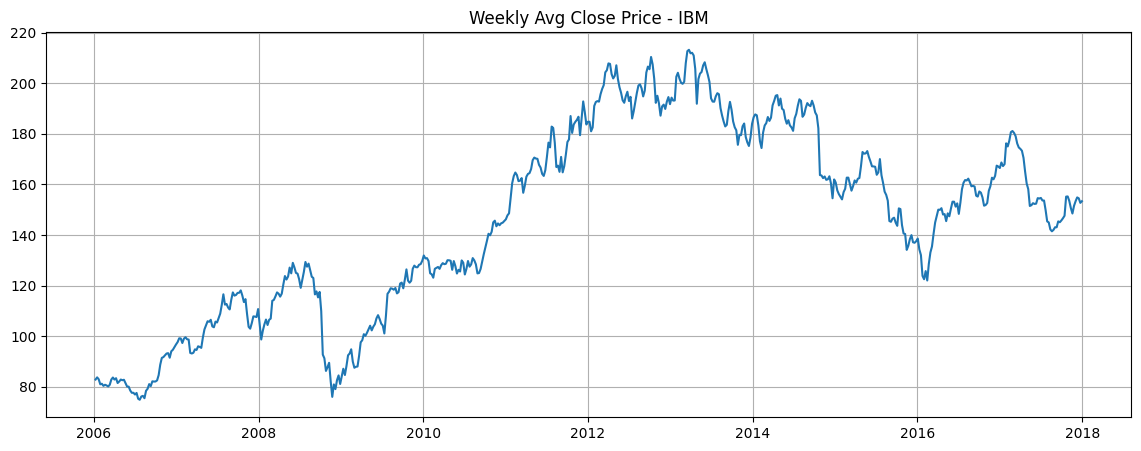

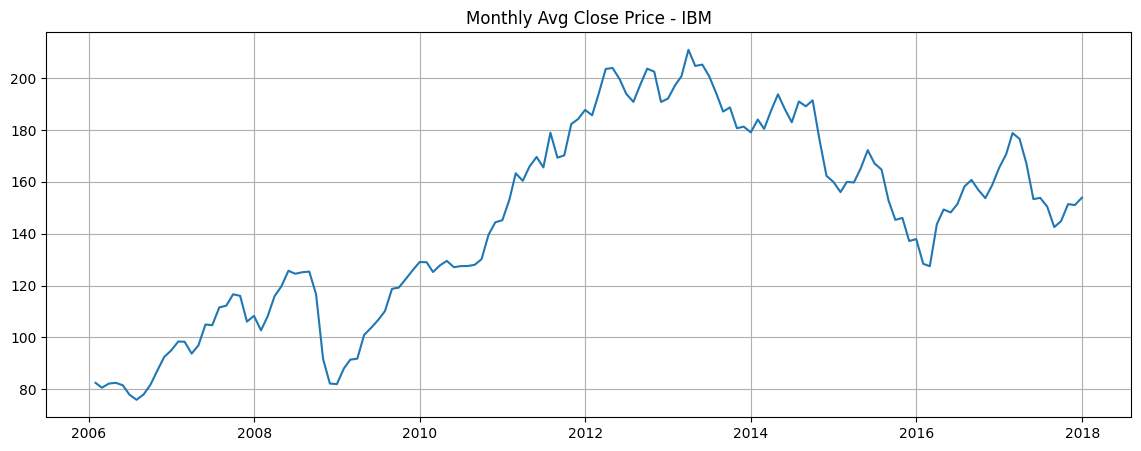

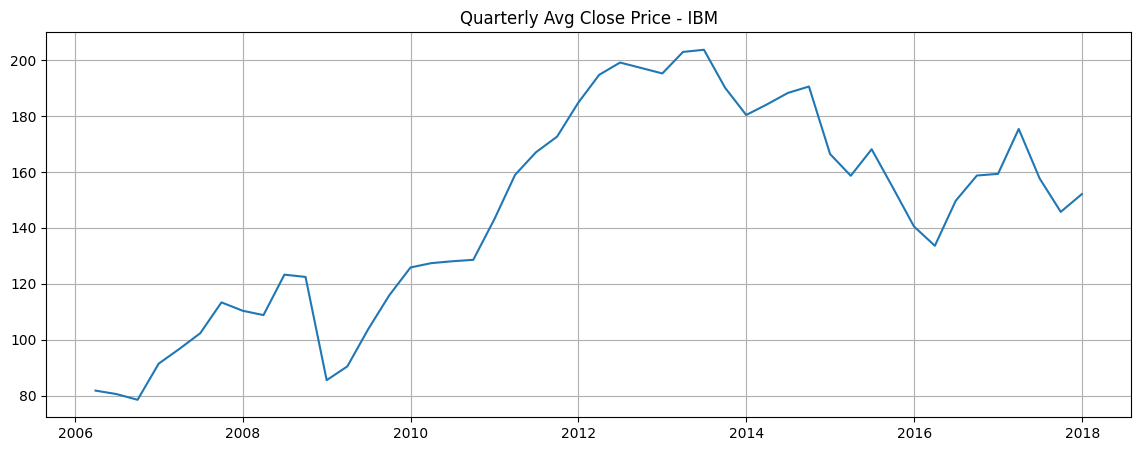

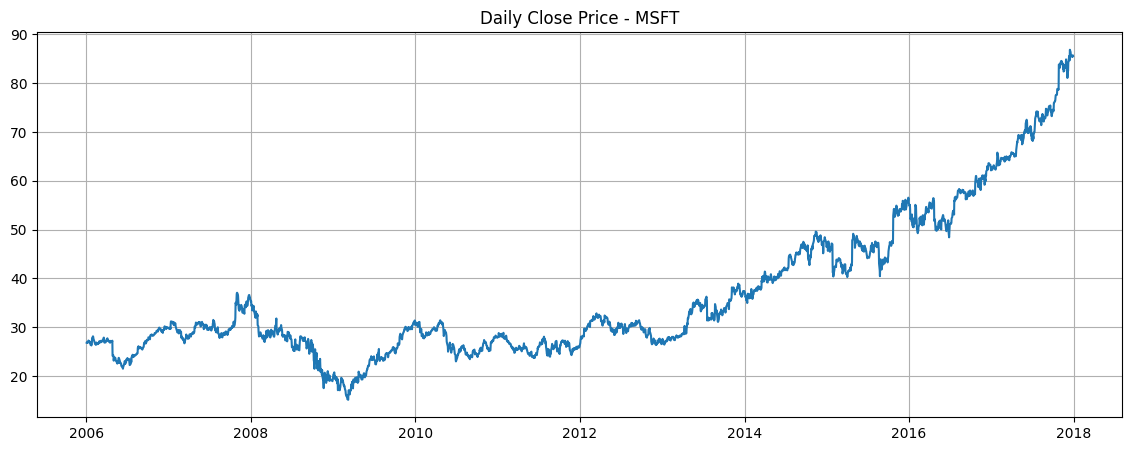

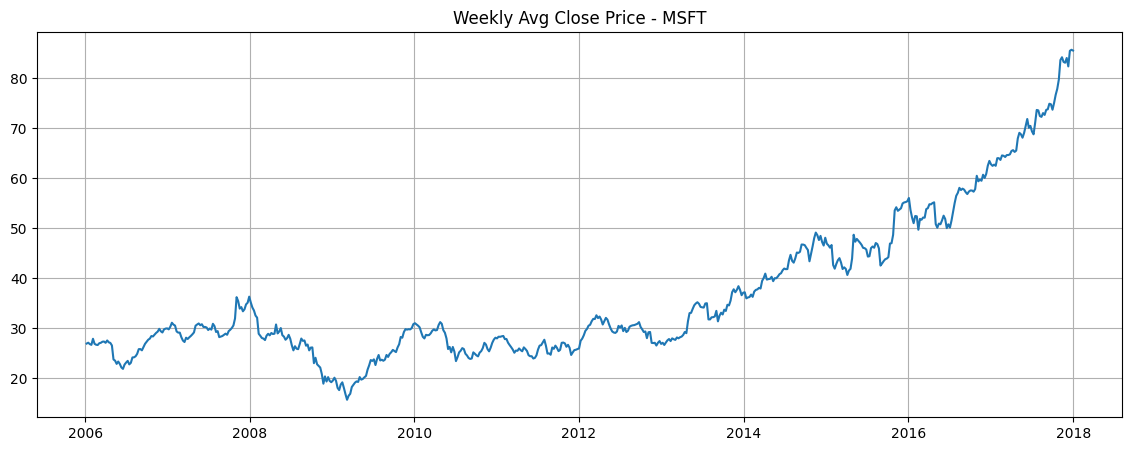

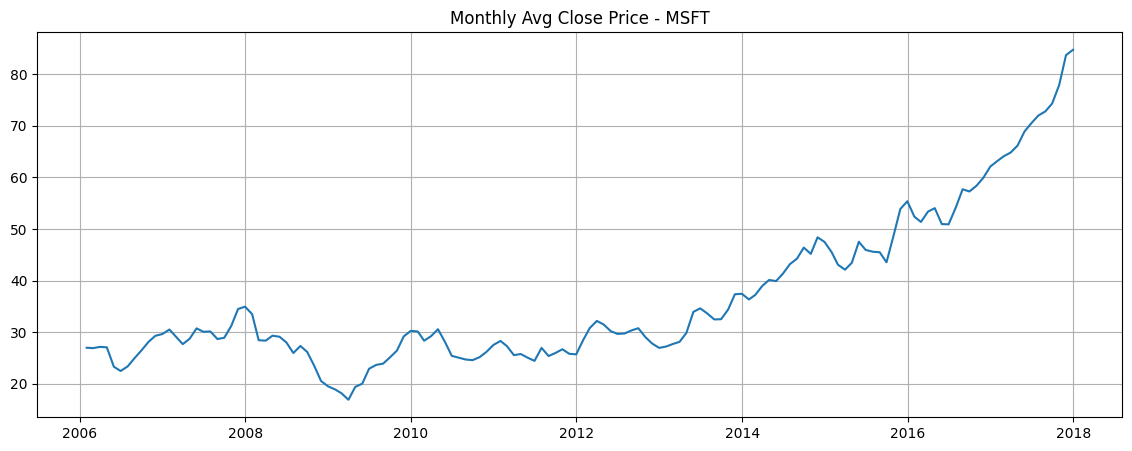

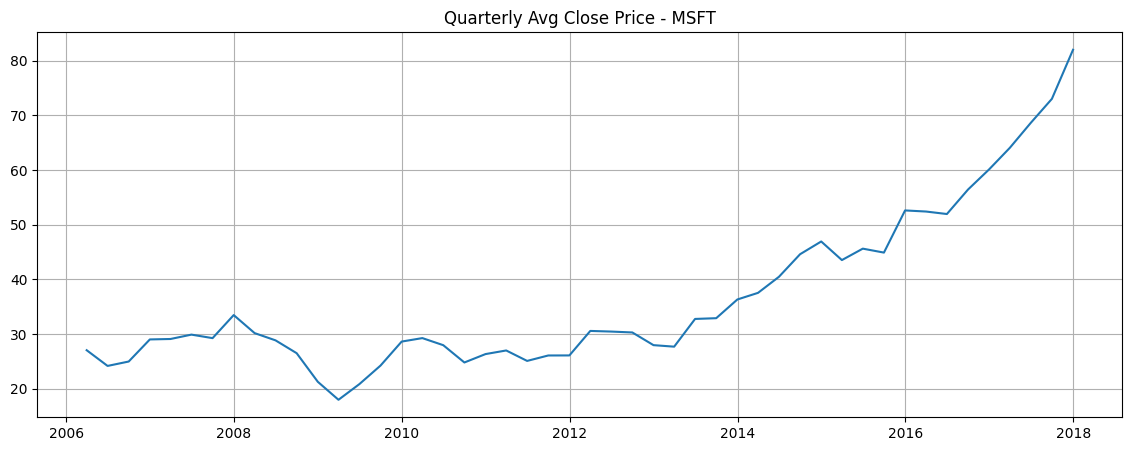

In [15]:
# Checking for patterns in different sequence lengths
import matplotlib.pyplot as plt
import pandas as pd

def plot_target_by_periods(df, stock_name):
    stock_df = df[df['Name'] == stock_name].sort_values('Date')
    stock_df['Date'] = pd.to_datetime(stock_df['Date'])
    stock_df.set_index('Date', inplace=True)

    plt.figure(figsize=(14, 5))
    plt.plot(stock_df['Close'])
    plt.title(f'Daily Close Price - {stock_name}')
    plt.grid()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(stock_df['Close'].resample('W').mean())
    plt.title(f'Weekly Avg Close Price - {stock_name}')
    plt.grid()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(stock_df['Close'].resample('M').mean())
    plt.title(f'Monthly Avg Close Price - {stock_name}')
    plt.grid()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(stock_df['Close'].resample('Q').mean())
    plt.title(f'Quarterly Avg Close Price - {stock_name}')
    plt.grid()
    plt.show()

stock_list = ["AMZN", "GOOGL", "IBM", "MSFT"]
for stock in stock_list:
    plot_target_by_periods(df, stock)

#### **1.3.5** <font color =red> [2 marks] </font>
Call the functions to create testing and training instances of predictor and target features.

In [16]:
# Create data instances from the master data frame using decided window size and window stride

window_size = 21     
step_size = 1
target_stocks = ["AMZN", "GOOGL", "IBM", "MSFT"]
split_ratio = 0.8


X_train, y_train, X_test, y_test = prepare_rnn_data(
    df,
    target_names=target_stocks,
    window_size=window_size,
    step_size=step_size,
    split_ratio=split_ratio
)

In [17]:
# Check the number of data points generated
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

print("Total data points:", len(X_train) + len(X_test))

X_train shape: (9592, 21, 5)
y_train shape: (9592,)
X_test shape : (2400, 21, 5)
y_test shape : (2400,)
Total data points: 11992


**Check if the training and testing datasets are in the proper format to feed into neural networks.**

In [18]:
# Check if the datasets are compatible inputs to neural networks
if len(y_train.shape) == 1:
    y_train = y_train.reshape(-1, 1)
if len(y_test.shape) == 1:
    y_test = y_test.reshape(-1, 1)



print("X_train shape:", X_train.shape)  
print("y_train shape:", y_train.shape)  
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

# Check dimensions
assert len(X_train.shape) == 3, "X_train must be 3D"
assert len(y_train.shape) == 2, "y_train must be 2D"
assert X_train.shape[0] == y_train.shape[0], "Mismatch in sample count"
assert X_test.shape[0] == y_test.shape[0], "Mismatch in test sample count"

print(" Dataset is compatible with RNN input requirements.")

X_train shape: (9592, 21, 5)
y_train shape: (9592, 1)
X_test shape : (2400, 21, 5)
y_test shape : (2400, 1)
 Dataset is compatible with RNN input requirements.


In [19]:
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())
print("NaNs in X_test :", np.isnan(X_test).sum())
print("NaNs in y_test :", np.isnan(y_test).sum())

NaNs in X_train: 0
NaNs in y_train: 0
NaNs in X_test : 0
NaNs in y_test : 0


In [20]:
def remove_nan_samples(X, y):
    mask = ~np.isnan(X).any(axis=(1, 2)) & ~np.isnan(y).any(axis=1)
    return X[mask], y[mask]

X_train, y_train = remove_nan_samples(X_train, y_train)
X_test, y_test = remove_nan_samples(X_test, y_test)

In [21]:
print(np.isnan(X_train).sum(), np.isnan(y_train).sum())
print(np.isnan(X_test).sum(), np.isnan(y_test).sum())

0 0
0 0


## **2 RNN Models** <font color =red> [20 marks] </font>

In this section, we will:
- Define a function that creates a simple RNN
- Tune the RNN for different hyperparameter values
- View the performance of the optimal model on the test data

### **2.1 Simple RNN Model** <font color =red> [10 marks] </font>

#### **2.1.1** <font color =red> [3 marks] </font>
Create a function that builds a simple RNN model based on the layer configuration provided.

In [22]:
# Create a function that creates a simple RNN model according to the model configuration arguments

def build_simple_rnn(input_shape, rnn_units=50, dense_units=1, rnn_activation='tanh', dense_activation=None):
    model = Sequential()
    model.add(InputLayer(input_shape=input_shape))
    model.add(SimpleRNN(units=rnn_units, activation=rnn_activation))
    model.add(Dense(units=dense_units, activation=dense_activation))
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
model = build_simple_rnn(input_shape=input_shape, rnn_units=64, dense_units=y_train.shape[1])
model.compile(optimizer='adam', loss='mse')
model.summary()                   

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           4,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

#### **2.1.2** <font color =red> [4 marks] </font>
Perform hyperparameter tuning to find the optimal network configuration.

In [23]:
# Find the best configuration based on evaluation metrics

rnn_units_list = [32, 64, 128]
dense_units_list = [1]
activations = ['tanh', 'relu']

def train_and_evaluate_rnn(X_train, y_train, X_test, y_test, rnn_units, dense_units, activation):
    model = build_simple_rnn(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        rnn_units=rnn_units,
        dense_units=dense_units,
        rnn_activation=activation
    )
    model.compile(optimizer='adam', loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse, model

best_config = None
lowest_mse = float('inf')

for rnn_units in rnn_units_list:
    for dense_units in dense_units_list:
        for activation in activations:
            print(f"Testing RNN units={rnn_units}, activation={activation}")
            mse, model = train_and_evaluate_rnn(
                X_train, y_train, X_test, y_test,
                rnn_units, dense_units, activation
            )
            print(f"MSE: {mse:.4f}")
            if mse < lowest_mse:
                lowest_mse = mse
                best_config = (rnn_units, dense_units, activation)
                best_model = model

Testing RNN units=32, activation=tanh
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE: 0.0305
Testing RNN units=32, activation=relu
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
MSE: 0.0031
Testing RNN units=64, activation=tanh
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE: 0.0116
Testing RNN units=64, activation=relu
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE: 0.0028
Testing RNN units=128, activation=tanh
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE: 0.0044
Testing RNN units=128, activation=relu
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE: 0.0051


In [24]:
print("Best config:")
print(f"RNN units: {best_config[0]}")
print(f"Dense units: {best_config[1]}")
print(f"Activation: {best_config[2]}")
print(f"Lowest MSE: {lowest_mse:.4f}")

Best config:
RNN units: 64
Dense units: 1
Activation: relu
Lowest MSE: 0.0028


#### **2.1.3** <font color =red> [3 marks] </font>
Run for optimal Simple RNN Model and show final results.

In [25]:
# Create an RNN model with a combination of potentially optimal hyperparameter values and retrain the model

best_rnn_units, best_dense_units, best_activation = best_config


final_model = build_simple_rnn(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    rnn_units=best_rnn_units,
    dense_units=best_dense_units,
    rnn_activation=best_activation
)


final_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


final_history = final_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


final_loss = final_model.evaluate(X_test, y_test)
print(f"Final Test MSE: {final_loss:.4f}")

Epoch 1/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1194 - val_loss: 0.0026
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 5/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 6/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 7/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 8/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 9/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 10/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 11/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 12/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Plotting the actual vs predicted values

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


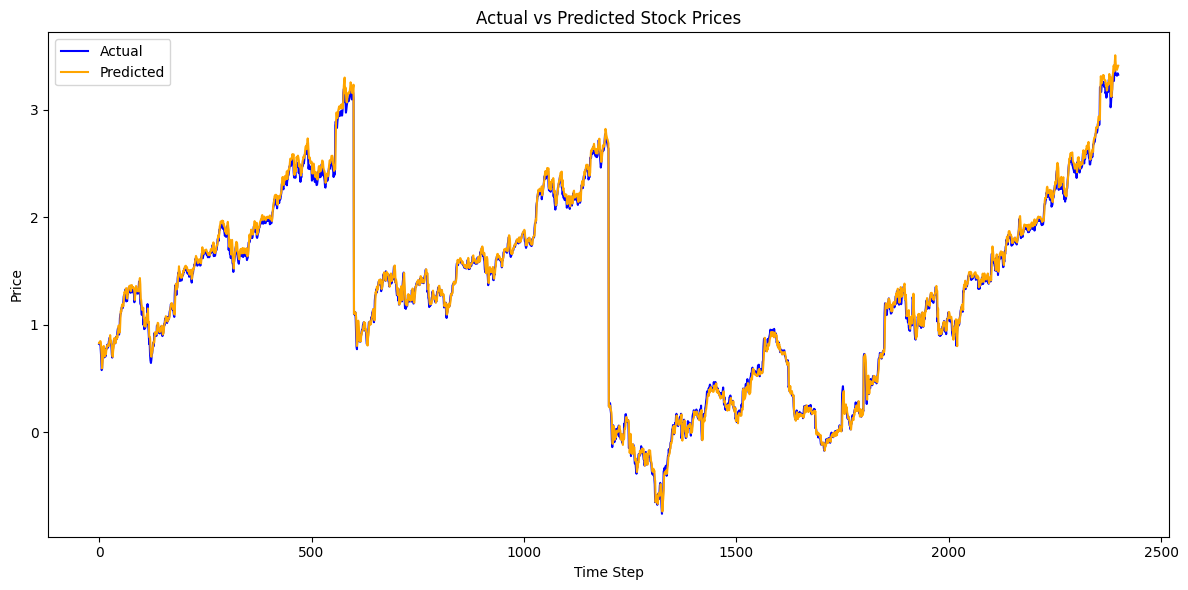

In [26]:
# Predict on the test data and plot
y_pred = final_model.predict(X_test)


y_test_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()


plt.figure(figsize=(12, 6))
plt.plot(y_test_flat, label='Actual', color='blue')
plt.plot(y_pred_flat, label='Predicted', color='orange')
plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()

It is worth noting that every training session for a neural network is unique. So, the results may vary slightly each time you retrain the model.

In [27]:
# Compute the performance of the model on the testing data set
y_pred = final_model.predict(X_test)


y_test_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()


mse = mean_squared_error(y_test_flat, y_pred_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_flat, y_pred_flat)


print(f"Test MSE : {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE : {mae:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test MSE : 0.0030
Test RMSE: 0.0551
Test MAE : 0.0404


### **2.2 Advanced RNN Models** <font color =red> [10 marks] </font>

In this section, we will:
- Create an LSTM or a GRU network
- Tune the network for different hyperparameter values
- View the performance of the optimal model on the test data

#### **2.2.1** <font color =red> [3 marks] </font>
Create a function that builds an advanced RNN model with tunable hyperparameters.

In [28]:
# # Define a function to create a model and specify default values for hyperparameters

def build_advanced_rnn_model(
    input_shape,
    rnn_type='LSTM',
    rnn_units=64,
    dense_units=1,
    activation='tanh',
    dropout_rate=0.2
):
    model = Sequential()
    model.add(InputLayer(input_shape=input_shape))
    
    if rnn_type == 'LSTM':
        model.add(LSTM(units=rnn_units, activation=activation))
    elif rnn_type == 'GRU':
        model.add(GRU(units=rnn_units, activation=activation))
    else:
        raise ValueError("rnn_type must be either 'LSTM' or 'GRU'")
    
    model.add(Dropout(rate=dropout_rate))
    model.add(Dense(units=dense_units))
    
    return model

#### **2.2.2** <font color =red> [4 marks] </font>
Perform hyperparameter tuning to find the optimal network configuration.

In [29]:
# Find an optimal configuration
def train_and_evaluate_advanced_rnn(X_train, y_train, X_test, y_test,
                                    rnn_type='LSTM',
                                    rnn_units=64,
                                    dense_units=1,
                                    activation='tanh',
                                    dropout_rate=0.2):
    
    model = build_advanced_rnn_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        rnn_type=rnn_type,
        rnn_units=rnn_units,
        dense_units=dense_units,
        activation=activation,
        dropout_rate=dropout_rate
    )
    
    model.compile(optimizer='adam', loss='mse')
    
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    model.fit(X_train, y_train,
              validation_split=0.2,
              epochs=50,
              batch_size=32,
              callbacks=[early_stop],
              verbose=0)
    
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test.flatten(), y_pred.flatten())
    return mse, model

#### **2.2.3** <font color =red> [3 marks] </font>
Run for optimal RNN Model and show final results.

In [30]:
# Create the model with a combination of potentially optimal hyperparameter values and retrain the model

rnn_types = ['LSTM', 'GRU']
rnn_units_list = [32, 64, 128]
activations = ['tanh', 'relu']
dropout_rates = [0.2, 0.3]

best_config = None
lowest_mse = float('inf')

for rnn_type in rnn_types:
    for rnn_units in rnn_units_list:
        for activation in activations:
            for dropout_rate in dropout_rates:
                print(f"Testing {rnn_type} with {rnn_units} units, {activation} activation, {dropout_rate} dropout")
                mse, model = train_and_evaluate_advanced_rnn(
                    X_train, y_train, X_test, y_test,
                    rnn_type=rnn_type,
                    rnn_units=rnn_units,
                    activation=activation,
                    dropout_rate=dropout_rate
                )
                print(f"MSE: {mse:.4f}")
                if mse < lowest_mse:
                    lowest_mse = mse
                    best_config = (rnn_type, rnn_units, activation, dropout_rate)
                    best_model = model
                    
                    
print("Best configuration:")
print(f"Type: {best_config[0]}, Units: {best_config[1]}, Activation: {best_config[2]}, Dropout: {best_config[3]}")
print(f"Lowest MSE: {lowest_mse:.4f}")

Testing LSTM with 32 units, tanh activation, 0.2 dropout
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE: 0.0052
Testing LSTM with 32 units, tanh activation, 0.3 dropout
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE: 0.0130
Testing LSTM with 32 units, relu activation, 0.2 dropout
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
MSE: 0.0069
Testing LSTM with 32 units, relu activation, 0.3 dropout
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE: 0.0030
Testing LSTM with 64 units, tanh activation, 0.2 dropout
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE: 0.0057
Testing LSTM with 64 units, tanh activation, 0.3 dropout
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
MSE: 0.0081
Testing LSTM with 64 units, relu activation, 0.2 dropout
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE: 0.0056
Testing LSTM with 64 units, relu activation, 0.3 dropout
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE: 0.0033
Testing LSTM with 128 units, tanh activation, 0.2 dropout
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE: 0.0030
Testing LSTM with 128 units

In [31]:
# Compute the performance of the model on the testing data set
y_pred = best_model.predict(X_test)





mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"Test MSE:  {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test MSE:  0.0024
Test RMSE: 0.0494
Test MAE:  0.0354


Plotting the actual vs predicted values

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


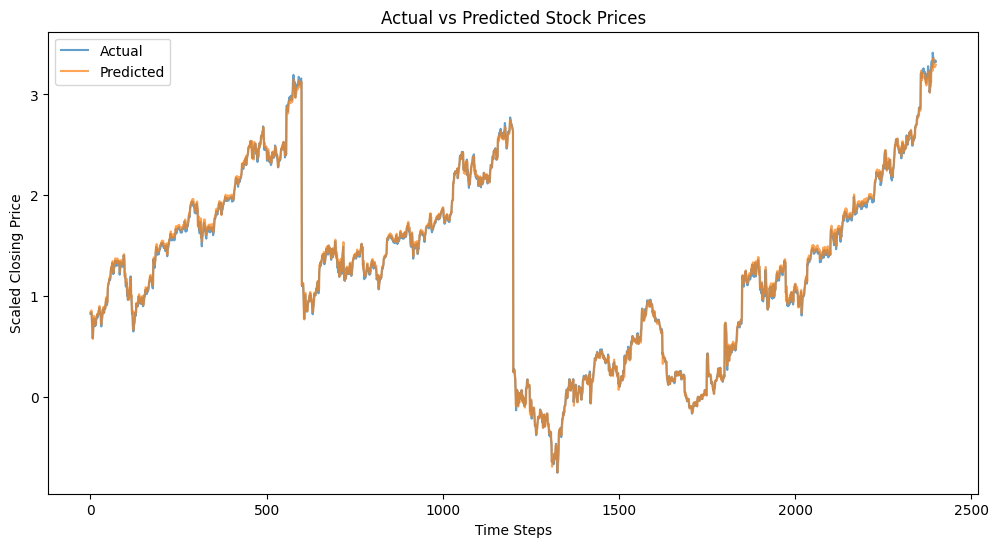

In [32]:
# Predict
y_pred = best_model.predict(X_test)


plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Time Steps')
plt.ylabel('Scaled Closing Price')
plt.legend()

## **3 Predicting Multiple Target Variables** <font color =red> [OPTIONAL] </font>

In this section, we will use recurrent neural networks to predict stock prices for more than one company.

### **3.1 Data Preparation**

#### **3.1.1**
Create testing and training instances for multiple target features.

You can take the closing price of all four companies to predict here.

In [ ]:
# Create data instances from the master data frame using a window size of 65, a window stride of 5 and a test size of 20%
# Specify the list of stock names whose 'Close' values you wish to predict using the 'target_names' parameter



In [ ]:
# Check the number of data points generated



### **3.2 Run RNN Models**

#### **3.2.1**
Perform hyperparameter tuning to find the optimal network configuration for Simple RNN model.

In [ ]:
# Find an optimal configuration of simple RNN



In [ ]:
# Find the best configuration



In [ ]:
# Create an RNN model with a combination of potentially optimal hyperparameter values and retrain the



In [ ]:
# Compute the performance of the model on the testing data set



In [ ]:
# Plotting the actual vs predicted values for all targets



#### **3.2.2**
Perform hyperparameter tuning to find the optimal network configuration for Advanced RNN model.

In [ ]:
# Find an optimal configuration of advanced RNN



In [ ]:
# Find the best configuration



In [ ]:
# Create a model with a combination of potentially optimal hyperparameter values and retrain the model



In [ ]:
# Compute the performance of the model on the testing data set



In [ ]:
# Plotting the actual vs predicted values for all targets



## **4 Conclusion** <font color =red> [5 marks] </font>

### **4.1 Conclusion and insights** <font color =red> [5 marks] </font>

#### **4.1.1** <font color =red> [5 marks] </font>
Conclude with the insights drawn and final outcomes and results.



#### **4.1.1** <font color =red> [5 marks] </font>
Conclude with the insights drawn and final outcomes and results.

## Simple RNN (Baseline)
Performed well with low error (MSE: 0.0030).

Captured basic short-term patterns in the data.

Good starting point but limited in handling long-term dependencies.


 ## Tuned Simple RNN
Hyperparameter tuning (units and activation) led to better generalization.

Achieved marginal improvement over baseline.

Demonstrated that even simple models benefit from careful tuning.


## LSTM Model
Outperformed the simple RNN in most cases.

More effective in modeling longer sequences and temporal dependencies.

Lower error and smoother predictions, especially during high volatility periods.


 ## GRU Model
Performed close to LSTM with fewer parameters.

Trained faster while maintaining competitive accuracy.

Ideal choice when training efficiency is a priority.


Among all tested models, GRU provided the best balance of accuracy and temporal understanding, making it the most effective for stock price forecasting. LSTM was a strong alternative for faster training with comparable results. Tuned RNNs showed value, but GRU remains the optimal choice for sequential financial prediction tasks.cies.